In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [32]:
df = pd.read_csv("../Data/hotel_bookings_cleaned.csv")

In [33]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(84224, 28)


In [34]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 84224 entries, 0 to 84223
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           84224 non-null  str    
 1   is_canceled                     84224 non-null  int64  
 2   arrival_date_year               84224 non-null  int64  
 3   arrival_date_month              84224 non-null  str    
 4   stays_in_weekend_nights         84224 non-null  int64  
 5   stays_in_week_nights            84224 non-null  int64  
 6   adults                          84224 non-null  int64  
 7   children                        84224 non-null  float64
 8   country                         84224 non-null  str    
 9   market_segment                  84224 non-null  str    
 10  is_repeated_guest               84224 non-null  int64  
 11  previous_cancellations          84224 non-null  int64  
 12  previous_bookings_not_

In [35]:
df.describe(include='all')

,hotel,is_canceled,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,country,market_segment,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,lead_time,total_nights,total_guests,planner_type,season
count,84224,84224.000000,84224.000000,84224,84224.000000,84224.000000,84224.000000,84224.000000,84224,84224,...,84224.000000,84224.000000,84224.000000,84224,84224,84224.000000,84224.000000,84224.000000,84224,84224
unique,2,NaN,NaN,12,NaN,NaN,NaN,NaN,175,7,...,NaN,NaN,NaN,3,925,NaN,NaN,NaN,3,4
top,City Hotel,NaN,NaN,August,NaN,NaN,NaN,NaN,PRT,Online TA,...,NaN,NaN,NaN,Check-Out,14-02-2016,NaN,NaN,NaN,Early Planner,Summer
freq,52531,NaN,NaN,9822,NaN,NaN,NaN,NaN,26501,49714,...,NaN,NaN,NaN,61226,209,NaN,NaN,NaN,38153,26845
mean,NaN,0.273058,2016.201344,NaN,1.003954,2.617603,1.869716,0.118209,NaN,NaN,...,102.030652,0.081295,0.694909,NaN,NaN,80.376235,3.621557,1.987925,NaN,NaN
std,NaN,0.445533,0.685884,NaN,1.029582,2.047902,0.627482,0.416967,NaN,NaN,...,45.091552,0.277172,0.827874,NaN,NaN,86.446009,2.753088,0.756865,NaN,NaN
min,NaN,0.000000,2015.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,-6.380000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,2016.000000,NaN,0.000000,1.000000,2.000000,0.000000,NaN,NaN,...,71.600000,0.000000,0.000000,NaN,NaN,11.000000,2.000000,2.000000,NaN,NaN
50%,NaN,0.000000,2016.000000,NaN,1.000000,2.000000,2.000000,0.000000,NaN,NaN,...,97.000000,0.000000,0.000000,NaN,NaN,50.000000,3.000000,2.000000,NaN,NaN
75%,NaN,1.000000,2017.000000,NaN,2.000000,3.000000,2.000000,0.000000,NaN,NaN,...,130.000000,0.000000,1.000000,NaN,NaN,126.000000,5.000000,2.000000,NaN,NaN


In [36]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

Series([], dtype: int64)


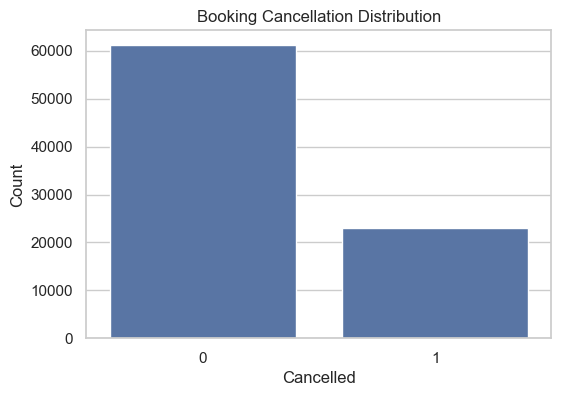

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='is_canceled')
plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancelled")
plt.ylabel("Count")
plt.show()

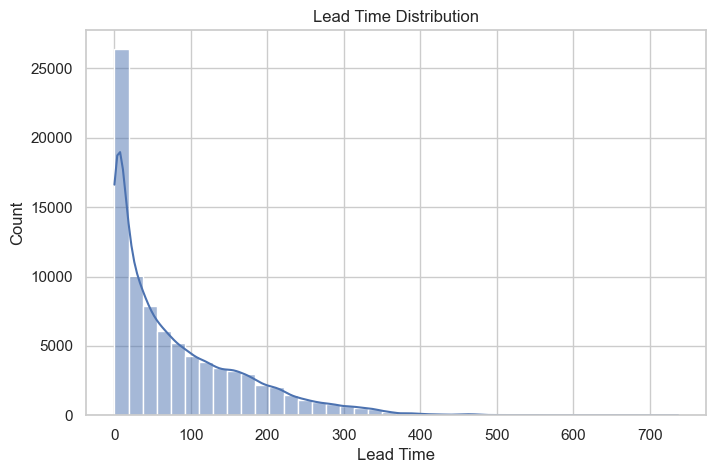

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['lead_time'],bins=40,kde=True)
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time")
plt.show()

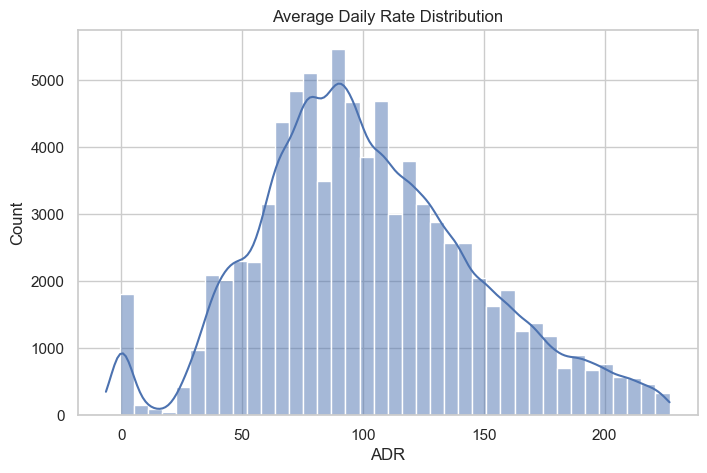

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df['adr'],bins=40,kde=True)
plt.title("Average Daily Rate Distribution")
plt.xlabel("ADR")
plt.show()

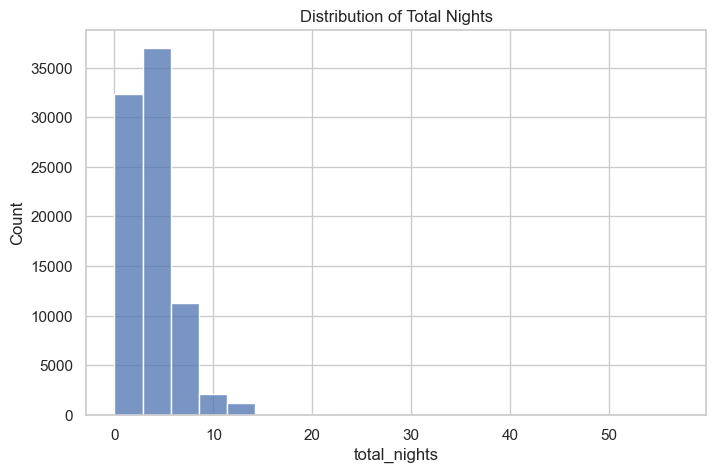

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_nights'],bins=20)
plt.title("Distribution of Total Nights")
plt.show()

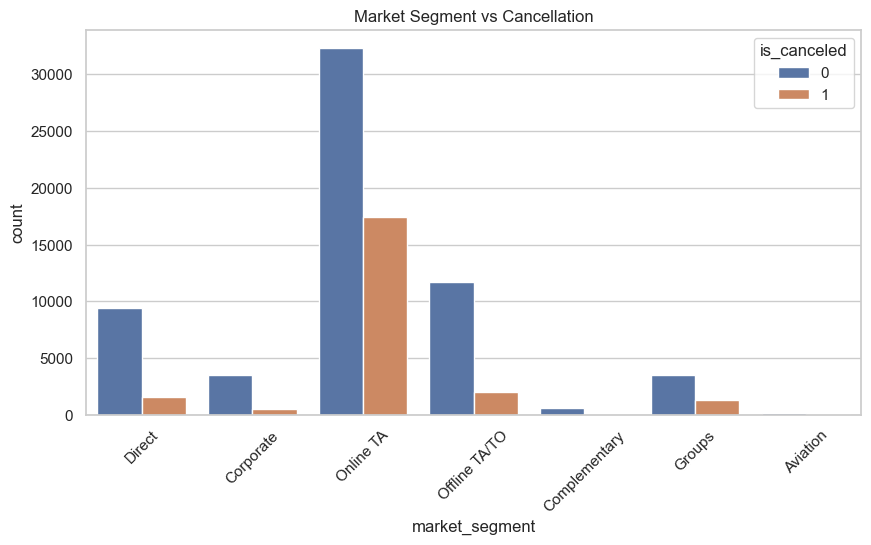

In [41]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='market_segment',hue='is_canceled')
plt.xticks(rotation=45)
plt.title("Market Segment vs Cancellation")
plt.show()

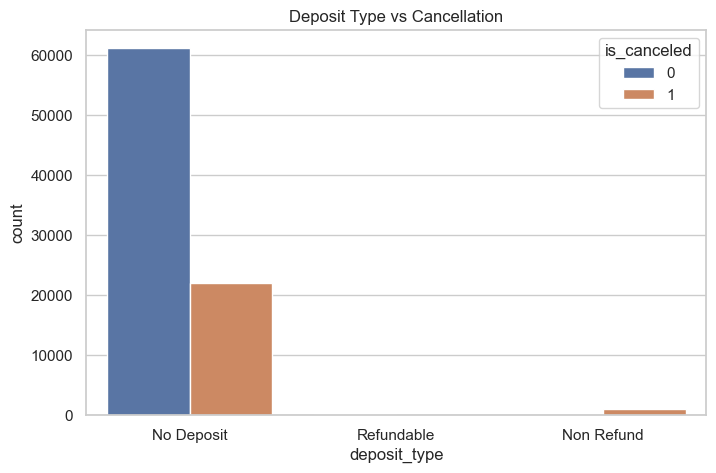

In [42]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='deposit_type',hue='is_canceled')
plt.title("Deposit Type vs Cancellation")
plt.show()

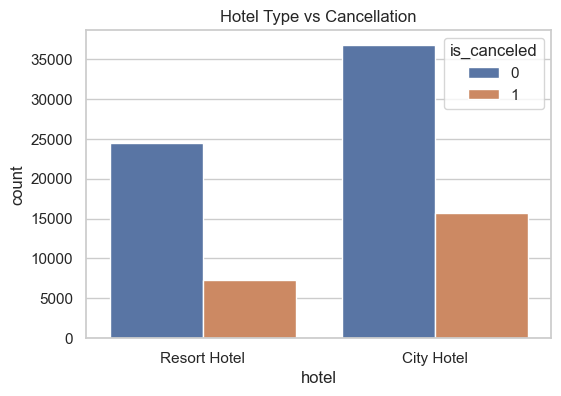

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='hotel',hue='is_canceled')
plt.title("Hotel Type vs Cancellation")
plt.show()

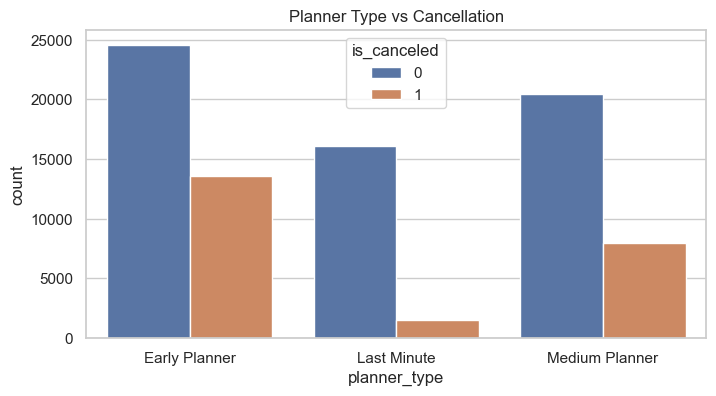

In [44]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x='planner_type',hue='is_canceled')
plt.title("Planner Type vs Cancellation")
plt.show()

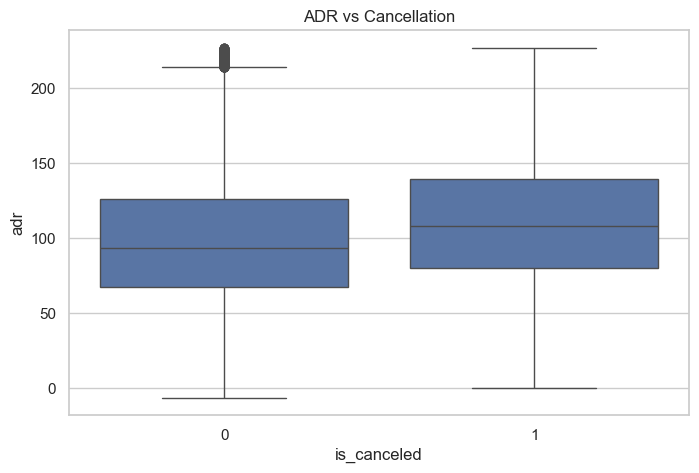

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='is_canceled',y='adr')
plt.title("ADR vs Cancellation")
plt.show()

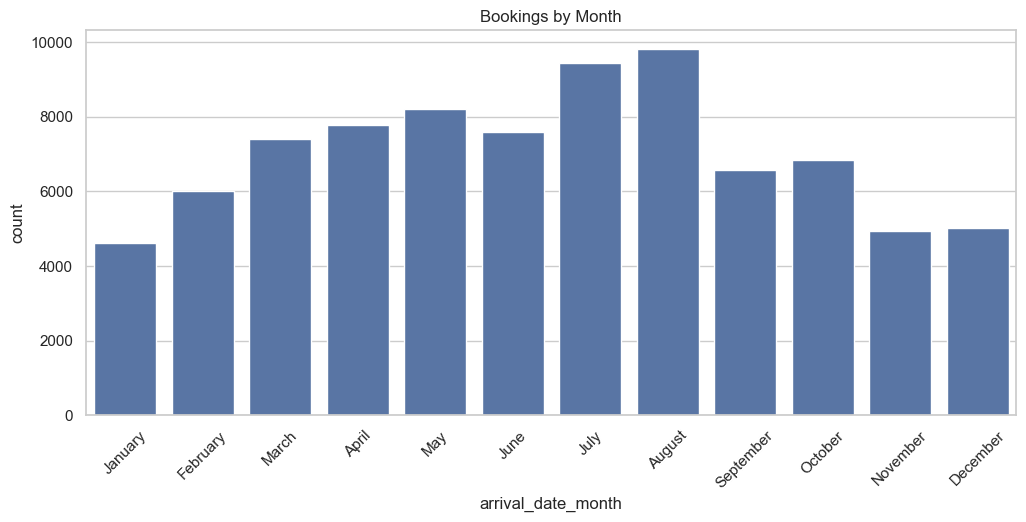

In [46]:
months = [
'January','February','March','April',
'May','June','July','August',
'September','October','November','December'
]
plt.figure(figsize=(12,5))
sns.countplot(data=df,x='arrival_date_month',order=months)
plt.xticks(rotation=45)
plt.title("Bookings by Month")
plt.show()

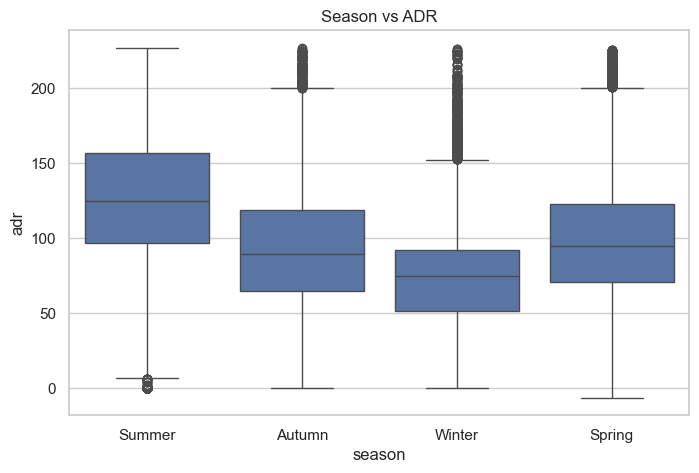

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='season',y='adr')
plt.title("Season vs ADR")
plt.show()

In [48]:
num = df.select_dtypes(include=['int64','float64'])

In [49]:
corr = num.corr()
corr

,is_canceled,arrival_date_year,stays_in_weekend_nights,stays_in_week_nights,adults,children,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,lead_time,total_nights,total_guests
is_canceled,1.000000,0.084411,0.055885,0.079202,0.080281,0.057422,-0.089945,0.051988,-0.050629,-0.092555,0.005590,0.132159,-0.179761,-0.116932,0.184619,0.079815,0.098191
arrival_date_year,0.084411,1.000000,0.002622,0.000496,0.030163,0.017869,0.026360,-0.053281,0.029990,0.006640,-0.026917,0.165694,-0.040946,0.059860,0.140927,0.001350,0.034851
stays_in_weekend_nights,0.055885,0.002622,1.000000,0.551474,0.087433,0.025020,-0.110054,-0.020783,-0.054676,0.048208,-0.031888,0.031368,-0.045770,0.030166,0.232360,0.784191,0.086270
stays_in_week_nights,0.079202,0.000496,0.551474,1.000000,0.094328,0.026727,-0.115994,-0.018861,-0.057198,0.084801,0.002206,0.042905,-0.047352,0.034231,0.310668,0.950093,0.092927
adults,0.080281,0.030163,0.087433,0.094328,1.000000,0.010034,-0.174507,-0.041591,-0.118042,-0.053275,-0.015297,0.254353,0.003690,0.111384,0.141632,0.102864,0.834581
children,0.057422,0.017869,0.025020,0.026727,0.010034,1.000000,-0.042869,-0.017638,-0.026540,0.031342,-0.018821,0.263199,0.030166,0.051782,0.028688,0.029237,0.559231
is_repeated_guest,-0.089945,0.026360,-0.110054,-0.115994,-0.174507,-0.042869,1.000000,0.207928,0.448720,0.005109,-0.013123,-0.179614,0.074434,-0.002787,-0.149867,-0.127440,-0.168293
previous_cancellations,0.051988,-0.053281,-0.020783,-0.018861,-0.041591,-0.017638,0.207928,1.000000,0.396027,-0.010357,0.003669,-0.054749,-0.002834,0.002053,0.005369,-0.021802,-0.044199
previous_bookings_not_canceled,-0.050629,0.029990,-0.054676,-0.057198,-0.118042,-0.026540,0.448720,0.396027,1.000000,0.006283,-0.006255,-0.093351,0.041732,0.027797,-0.077540,-0.062994,-0.112484
booking_changes,-0.092555,0.006640,0.048208,0.084801,-0.053275,0.031342,0.005109,-0.010357,0.006283,1.000000,0.025480,-0.014938,0.044416,0.011092,0.077241,0.081109,-0.026901


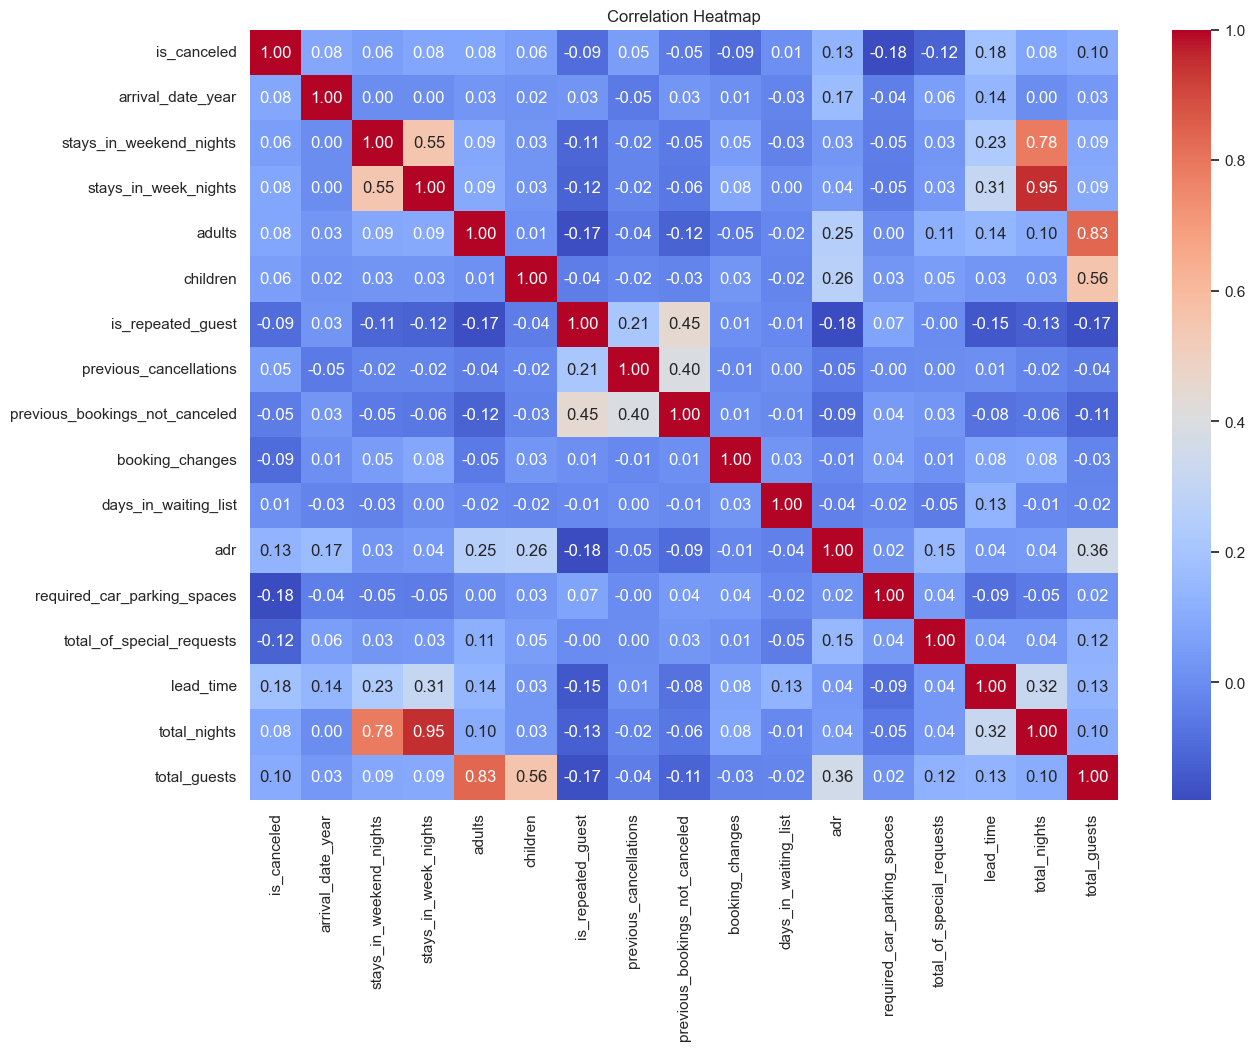

In [50]:
plt.figure(figsize=(14,10))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [51]:
cancelled = df[df['is_canceled']==1]['adr']
not_cancelled = df[df['is_canceled']==0]['adr']
t_stat,p_value = ttest_ind(cancelled,not_cancelled)
print("T Statistic :",t_stat)
print("P-value :",p_value)

T Statistic : 38.693259514624756
P-value : 0.0


In [52]:
if p_value < 0.05:
    print("Reject the Null Hypothesis")
    print("Average ADR differs significantly.")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis
Average ADR differs significantly.
